In [ ]:
# Gerekli kütüphaneleri kontrol edip kuruyoruz
# torch: tensör işlemleri ve sinir ağı katmanları için temel kütüphane
# torchvision: hazır modeller (Mask R-CNN dahil) ve görüntü dönüşümleri için
!pip install torch torchvision --quiet


In [ ]:
import torch                     # Ana derin öğrenme kütüphanesi (tensörler, autograd)
import torch.nn as nn            # Sinir ağı katmanlarını içerir (Conv2d, Linear, vb.)
import torch.nn.functional as F  # Aktivasyon fonksiyonları gibi durumsuz (stateless) işlemler
import numpy as np                # Sayısal işlemler ve dizi (array) manipülasyonu için

torch.manual_seed(42)  # Tekrar üretilebilirlik için rastgelelik tohumunu (seed) sabitliyoruz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU varsa kullan, yoksa CPU
print(f"Kullanılan cihaz: {device}")


Kullanılan cihaz: cpu


In [ ]:
class BasitCNN(nn.Module):
    """
    Basit bir görüntü sınıflandırma CNN'i.
    Giriş: (batch, 1, 28, 28) boyutunda gri tonlamalı görüntü
    Çıkış: (batch, 10) boyutunda sınıf skorları (logits)
    """
    def __init__(self, num_classes=10):
        super().__init__()  # nn.Module'ün kurucusunu çağırıyoruz (zorunlu)

        # --- 1. Konvolüsyon Bloğu ---
        # in_channels=1: gri tonlamalı görüntü (RGB olsaydı 3 olurdu)
        # out_channels=16: 16 farklı filtre öğrenilecek, yani 16 özellik haritası üretilecek
        # kernel_size=3: 3x3 boyutunda filtre
        # padding=1: kenarlarda bilgi kaybını önlemek için görüntü etrafına 1 piksel sıfır ekle
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)  # Eğitimi stabilize eden normalizasyon katmanı

        # --- 2. Konvolüsyon Bloğu ---
        # Bir önceki katmanın çıktısı (16 kanal) burada girdi olur, 32 kanala çıkarılır
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Havuzlama: her 2x2'lik alanın maksimumunu alarak boyutu yarıya indirir
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # İki kez pool uygulanacağı için: 28 -> 14 -> 7
        # Son özellik haritası boyutu: 32 kanal x 7 x 7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)   # Tam bağlantılı katman: özellikleri 128 boyuta indirir
        self.dropout = nn.Dropout(0.3)          # Aşırı öğrenmeyi (overfitting) azaltmak için nöronların %30'unu rastgele söndürür
        self.fc2 = nn.Linear(128, num_classes)  # Son katman: her sınıf için bir skor üretir

    def forward(self, x):
        # x boyutu: (batch, 1, 28, 28)

        x = self.conv1(x)          # Konvolüsyon uygula -> (batch, 16, 28, 28)
        x = self.bn1(x)            # Batch normalization uygula
        x = F.relu(x)              # Negatif değerleri 0 yapan aktivasyon fonksiyonu
        x = self.pool(x)           # Boyutu yarıya indir -> (batch, 16, 14, 14)

        x = self.conv2(x)          # İkinci konvolüsyon -> (batch, 32, 14, 14)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)           # -> (batch, 32, 7, 7)

        x = torch.flatten(x, 1)    # 2D özellik haritalarını 1D vektöre düzleştir -> (batch, 32*7*7)
        x = self.fc1(x)            # Tam bağlantılı katmandan geçir -> (batch, 128)
        x = F.relu(x)
        x = self.dropout(x)        # Dropout uygula (sadece eğitim sırasında aktif)
        x = self.fc2(x)            # Son katman -> (batch, num_classes) ham skorlar (logits)

        return x


In [ ]:
from PIL import Image
import torchvision.transforms as T

# Modeli oluşturup cihaza (CPU/GPU) taşıyoruz
model_cnn = BasitCNN(num_classes=10).to(device)
print(model_cnn)

# Veri setinden örnek bir görüntü alıp CNN formatına (1, 28, 28 gri tonlamalı) dönüştürüyoruz
img_path = '/content/train/10.jpg'
img = Image.open(img_path).convert('L') # Siyah-beyaz
transform_cnn = T.Compose([T.Resize((28, 28)), T.ToTensor()])
gercek_girdi = transform_cnn(img).unsqueeze(0).to(device) # (1, 1, 28, 28)

cikti = model_cnn(gercek_girdi)

print(f"\nGirdi boyutu : {gercek_girdi.shape}")
print(f"Çıktı boyutu : {cikti.shape}  # (batch_size=1, num_classes=10)")

BasitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Girdi boyutu : torch.Size([1, 1, 28, 28])
Çıktı boyutu : torch.Size([1, 10])  # (batch_size=1, num_classes=10)


In [ ]:
# Kayıp fonksiyonu: çok sınıflı sınıflandırma için standart seçim
criterion = nn.CrossEntropyLoss()

# Optimizer: ağırlıkları gradyanlara göre güncelleyen algoritma
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

# --- Tek bir eğitim adımı örneği (Gerçek görüntü ile) ---
sahte_etiketler = torch.tensor([1]).to(device)  # 1 örnek için rastgele etiket

optimizer.zero_grad()                    # Önceki adımdan kalan gradyanları sıfırla
cikti = model_cnn(gercek_girdi)          # İleri yayılım: gerçek görüntü ile tahminleri hesapla
loss = criterion(cikti, sahte_etiketler) # Tahmin ile etiket arasındaki hatayı hesapla
loss.backward()                          # Geri yayılım: her ağırlık için gradyanı hesapla
optimizer.step()                         # Ağırlıkları gradyana göre güncelle

print(f"Örnek eğitim adımı kaybı (loss): {loss.item():.4f}")

Örnek eğitim adımı kaybı (loss): 2.6751


In [ ]:
class ConvBlok(nn.Module):
    """
    U-Net'te tekrar tekrar kullanılan temel yapı taşı:
    (Konvolüsyon -> BatchNorm -> ReLU) x 2
    Bu blok hem encoder hem decoder tarafında kullanılır.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.blok = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),  # Uzamsal boyutu koru (padding=1)
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),  # İkinci konvolüsyon, kanal sayısı sabit kalır
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.blok(x)  # Sequential içindeki tüm katmanları sırayla uygula


In [ ]:
class UNet(nn.Module):
    """
    Basitleştirilmiş U-Net mimarisi.
    Giriş : (batch, in_ch, H, W)  -- örn. RGB görüntü (in_ch=3)
    Çıkış : (batch, num_classes, H, W) -- her piksel için sınıf skorları
    """
    def __init__(self, in_ch=3, num_classes=1, ozellikler=[64, 128, 256, 512]):
        super().__init__()

        self.encoder = nn.ModuleList()  # Daraltma yolundaki blokları tutacak liste
        self.decoder = nn.ModuleList()  # Genişletme yolundaki blokları tutacak liste
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Her encoder adımından sonra boyutu yarıya indirir

        # --- ENCODER (Daraltma Yolu) oluşturuluyor ---
        kanal = in_ch
        for f in ozellikler:
            self.encoder.append(ConvBlok(kanal, f))  # örn: 3->64, 64->128, 128->256, 256->512
            kanal = f

        # --- BOTTLENECK (En dar/derin katman, encoder ile decoder arasındaki köprü) ---
        self.bottleneck = ConvBlok(ozellikler[-1], ozellikler[-1] * 2)  # 512 -> 1024

        # --- DECODER (Genişletme Yolu) oluşturuluyor ---
        # Ozellikler listesini ters çeviriyoruz çünkü decoder küçükten büyüğe değil,
        # derinden (dar) sığa (geniş) doğru ilerler
        for f in reversed(ozellikler):
            # Transpoze konvolüsyon: özellik haritasının boyutunu 2 katına çıkarır (upsampling)
            self.decoder.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
            )
            # Skip connection ile birleştirildikten sonra kanal sayısı 2 katına çıkar (f*2),
            # bu yüzden ConvBlok girişi f*2 olarak ayarlanır
            self.decoder.append(ConvBlok(f * 2, f))

        # Son katman: kanal sayısını istenen sınıf sayısına indirir (1x1 konvolüsyon)
        self.son_katman = nn.Conv2d(ozellikler[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_baglantilari = []  # Her encoder seviyesinin çıktısını burada saklayacağız

        # --- Encoder'dan geçiş ---
        for enc_blok in self.encoder:
            x = enc_blok(x)                # Konvolüsyon bloğunu uygula
            skip_baglantilari.append(x)    # Havuzlamadan ÖNCEKİ hali sakla (decoder'a taşınacak)
            x = self.pool(x)               # Boyutu yarıya indir

        # --- Bottleneck ---
        x = self.bottleneck(x)  # En derin katman

        # Skip bağlantılarını decoder'da kullanmak için ters çeviriyoruz
        # (en son eklenen encoder çıktısı, decoder'da en önce kullanılır)
        skip_baglantilari = skip_baglantilari[::-1]

        # --- Decoder'dan geçiş ---
        # self.decoder listesinde ikişerli gidiyoruz: [upsample, convblok, upsample, convblok, ...]
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)                    # Transpoze konvolüsyon ile boyutu büyüt
            skip = skip_baglantilari[i // 2]           # İlgili encoder seviyesinin sakladığı özellik haritası

            # Boyutlar (yuvarlama hatalarından dolayı) tam eşleşmeyebilir, gerekirse kırp
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])  # skip ile aynı H,W boyutuna getir

            x = torch.cat((skip, x), dim=1)           # KRİTİK ADIM: skip connection -> kanal boyutunda birleştir
            x = self.decoder[i + 1](x)                # ConvBlok ile işle

        return self.son_katman(x)  # Son 1x1 konvolüsyon ile sınıf haritasını üret


In [ ]:
# U-Net modelini oluşturuyoruz: 3 kanallı (RGB) girdi, 1 sınıflı çıktı (örn. ikili segmentasyon: nesne/arkaplan)
model_unet = UNet(in_ch=3, num_classes=1).to(device)

# Veri setinden görüntüyü U-Net için (3, 160, 160) formatında hazırlıyoruz
img_unet = Image.open('/content/train/10.jpg').convert('RGB')
transform_unet = T.Compose([T.Resize((160, 160)), T.ToTensor()])
gercek_goruntu_unet = transform_unet(img_unet).unsqueeze(0).to(device)

maske_ciktisi = model_unet(gercek_goruntu_unet)

print(f"Girdi boyutu : {gercek_goruntu_unet.shape}")
print(f"Çıktı boyutu : {maske_ciktisi.shape}  # Girdiyle aynı H,W -> piksel bazlı segmentasyon haritası")

# Toplam öğrenilebilir parametre sayısı
toplam_param = sum(p.numel() for p in model_unet.parameters())
print(f"Toplam parametre sayısı: {toplam_param:,}")

Girdi boyutu : torch.Size([1, 3, 160, 160])
Çıktı boyutu : torch.Size([1, 1, 160, 160])  # Girdiyle aynı H,W -> piksel bazlı segmentasyon haritası
Toplam parametre sayısı: 31,043,521


In [ ]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def mask_rcnn_olustur(num_classes):
    """
    COCO veri setiyle önceden eğitilmiş (pretrained) Mask R-CNN modelini yükler
    ve son katmanlarını kendi sınıf sayımıza göre değiştirir (transfer learning).

    num_classes: arkaplan dahil toplam sınıf sayısı (örn. 2 = arkaplan + 1 nesne sınıfı)
    """
    # weights="DEFAULT": ImageNet/COCO üzerinde önceden eğitilmiş ağırlıkları indirir
    # Bu sayede sıfırdan eğitmek yerine, öğrenilmiş genel görsel özelliklerden faydalanırız
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # --- 1. Sınıflandırma + Kutu Regresyon Başlığını Değiştir ---
    in_features = model.roi_heads.box_predictor.cls_score.in_features  # Mevcut özellik boyutunu al
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # --- 2. Maske Başlığını Değiştir ---
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Maske başlığındaki gizli katman boyutu
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model


In [ ]:
# Örnek: arkaplan + 2 nesne sınıfı (toplam 3 sınıf) için model oluşturuyoruz
NUM_CLASSES = 3  # örn: 0=arkaplan, 1=kedi, 2=köpek
model_maskrcnn = mask_rcnn_olustur(NUM_CLASSES).to(device)
model_maskrcnn.eval()  # Değerlendirme (inference) moduna al (BatchNorm/Dropout davranışını sabitler)

print("Mask R-CNN modeli başarıyla oluşturuldu.")
print(f"Toplam parametre sayısı: {sum(p.numel() for p in model_maskrcnn.parameters()):,}")


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 358MB/s]


Mask R-CNN modeli başarıyla oluşturuldu.
Toplam parametre sayısı: 43,927,777


In [ ]:
# --- Çıkarım (Inference) Örneği ---
# Mask R-CNN, girdi olarak [0,1] aralığında normalize edilmiş RGB görüntü listesi bekler

# Gerçek hasar veri setinden bir görüntüyü Tensor formatına çeviriyoruz
img_rcnn = Image.open('/content/train/10.jpg').convert('RGB')
transform_rcnn = T.ToTensor()
gercek_goruntu_rcnn = transform_rcnn(img_rcnn).to(device)

gercek_goruntu_listesi = [gercek_goruntu_rcnn]  # 1 adet gerçek RGB görüntü

with torch.no_grad():  # Çıkarım sırasında gradyan hesaplamayı kapatıyoruz (bellek/hız için)
    tahminler = model_maskrcnn(gercek_goruntu_listesi)

# Model her görüntü için bir sözlük (dict) döndürür:
tek_goruntu_sonucu = tahminler[0]
print("Çıktı anahtarları:", tek_goruntu_sonucu.keys())
print(f"Tespit edilen kutu sayısı : {tek_goruntu_sonucu['boxes'].shape}")
print(f"Maske tensör boyutu       : {tek_goruntu_sonucu['masks'].shape}")
print(f"Skor örnekleri (ilk 5)    : {tek_goruntu_sonucu['scores'][:5]}")

Çıktı anahtarları: dict_keys(['boxes', 'labels', 'scores', 'masks'])
Tespit edilen kutu sayısı : torch.Size([100, 4])
Maske tensör boyutu       : torch.Size([100, 1, 1024, 1024])
Skor örnekleri (ilk 5)    : tensor([0.5714, 0.5651, 0.5583, 0.5571, 0.5561])



## Gerçek Veri Seti Uygulaması: Coco Car Damage Detection


In [ ]:
# COCO formatındaki JSON dosyalarını kolayca okuyabilmek için gerekli kütüphane
!pip install pycocotools --quiet

In [ ]:
import os
import torch
import torch.utils.data
import torchvision.transforms as T
from PIL import Image
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class CocoCarDamageDataset(torch.utils.data.Dataset):
    def __init__(self, root, annotation, transforms=None):
        self.root = root
        self.transforms = transforms
        self.coco = COCO(annotation)
        self.ids = list(sorted(self.coco.imgs.keys()))

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        coco_annotation = coco.loadAnns(ann_ids)

        path = coco.loadImgs(img_id)[0]['file_name']
        img = Image.open(os.path.join(self.root, path)).convert('RGB')

        num_objs = len(coco_annotation)

        boxes = []
        masks = []
        labels = []

        for i in range(num_objs):
            xmin = coco_annotation[i]['bbox'][0]
            ymin = coco_annotation[i]['bbox'][1]
            xmax = xmin + coco_annotation[i]['bbox'][2]
            ymax = ymin + coco_annotation[i]['bbox'][3]

            # Geçerli kutuları (bounding box) ekle
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
                masks.append(coco.annToMask(coco_annotation[i]))
                labels.append(coco_annotation[i]['category_id'])

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            masks = torch.as_tensor(masks, dtype=torch.uint8)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            # Nesne bulunamadığı durumlar için boş tensörler
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, img.size[1], img.size[0]), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = torch.tensor([img_id])

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

Toplam eğitim görüntüsü sayısı: 59


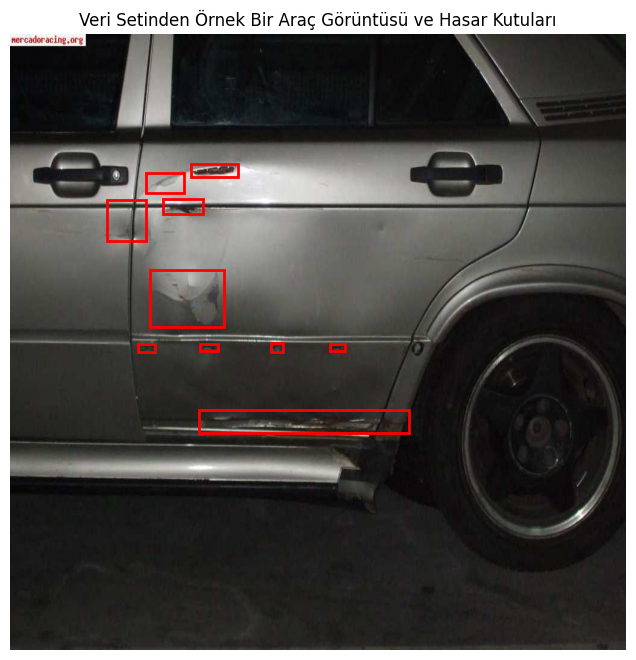

In [ ]:
# Veri setini oluşturma ve test etme
train_data_dir = '/content/train'
train_coco_json = '/content/train/COCO_train_annos.json'

# Görüntüleri PyTorch Tensörüne dönüştüren yardımcı fonksiyon
def get_transform():
    return T.Compose([T.ToTensor()])

# Dataset nesnemizi başlatıyoruz
dataset = CocoCarDamageDataset(root=train_data_dir,
                               annotation=train_coco_json,
                               transforms=get_transform())

print(f"\nToplam eğitim görüntüsü sayısı: {len(dataset)}")

# Veri setinden örnek bir görüntü ve hedef(target) alalım
img, target = dataset[0]

# Görüntüleme (matplotlib formatı için tensörü HWC şekline getiriyoruz)
img_np = img.permute(1, 2, 0).numpy()
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(img_np)

# Bounding Box'ları görüntü üzerine çizelim
for box in target['boxes']:
    xmin, ymin, xmax, ymax = box.numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.title("Veri Setinden Örnek Bir Araç Görüntüsü ve Hasar Kutuları")
plt.axis('off')
plt.show()

In [ ]:
# Yüklediğimiz gerçek veri seti için Mask R-CNN modelini ayarlıyoruz
# category_id'leri hesaba katarak +1 arkaplan (background) sınıfını ekliyoruz.
NUM_CLASSES_DAMAGE = len(dataset.coco.cats) + 1

print(f"Mask R-CNN Modeli {NUM_CLASSES_DAMAGE} sınıf (Arkaplan + Hasar Tipleri) için oluşturuluyor...")

# Yukarıda tanımladığımız mask_rcnn_olustur fonksiyonunu kullanıyoruz
model_damage = mask_rcnn_olustur(NUM_CLASSES_DAMAGE).to(device)

# Önceden ağırlıkları sıfırlanmış modeli test etmek için bir çıkarım yapalım
model_damage.eval()
with torch.no_grad():
    prediction = model_damage([img.to(device)])

print("\nModel başarılı bir şekilde yeni veri setine uyarlandı ve veri setinden veri alabildi!")
print(f"Tahmin edilen nesne sayısı: {len(prediction[0]['boxes'])}")

Mask R-CNN Modeli 2 sınıf (Arkaplan + Hasar Tipleri) için oluşturuluyor...

Model başarılı bir şekilde yeni veri setine uyarlandı ve veri setinden veri alabildi!
Tahmin edilen nesne sayısı: 100
